#  peek at all 3 files:

In [1]:
import pandas as pd
df = pd.read_csv("../data/fraudTrain.csv", nrows=5)
print(df.columns.tolist())

['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


In [2]:
df = pd.read_csv("../data/fraudTest.csv", nrows=5)
print(df.columns.tolist())

['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


In [3]:
df = pd.read_csv("../data/creditcard.csv", nrows=5)
print(df.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


# check shape

In [4]:
for file in ["fraudTrain.csv", "fraudTest.csv", "creditcard.csv"]:
    df = pd.read_csv(f"../data/{file}")
    print(f"{file}: {df.shape[0]:,} rows x {df.shape[1]} cols")

fraudTrain.csv: 1,296,675 rows x 23 cols
fraudTest.csv: 555,719 rows x 23 cols
creditcard.csv: 284,807 rows x 31 cols


# check nulls and fraud split:

In [6]:
df_train = pd.read_csv("../data/fraudTrain.csv")
print(df_train.isnull().sum())
print(df_train['is_fraud'].value_counts(normalize=True).mul(100).round(2))

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64
is_fraud
0    99.42
1     0.58
Name: proportion, dtype: float64


In [8]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../data/credit_risk.db")

queries = {
    "Row counts": """
        SELECT 'transactions' AS table_name, COUNT(*) AS total_rows FROM transactions
        UNION ALL
        SELECT 'creditcard', COUNT(*) FROM creditcard
    """,
    "Fraud split - transactions": """
        SELECT 
            CASE is_fraud WHEN 1 THEN 'Fraud' ELSE 'Legit' END AS label,
            COUNT(*) AS total,
            ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM transactions), 3) AS pct
        FROM transactions GROUP BY is_fraud
    """,
    "Fraud split - creditcard": """
        SELECT 
            CASE Class WHEN 1 THEN 'Fraud' ELSE 'Legit' END AS label,
            COUNT(*) AS total,
            ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM creditcard), 3) AS pct
        FROM creditcard GROUP BY Class
    """,
    "Amount stats by fraud label": """
        SELECT
            CASE is_fraud WHEN 1 THEN 'Fraud' ELSE 'Legit' END AS label,
            ROUND(MIN(amt), 2) AS min_amt,
            ROUND(MAX(amt), 2) AS max_amt,
            ROUND(AVG(amt), 2) AS avg_amt
        FROM transactions GROUP BY is_fraud
    """
}

for title, query in queries.items():
    print(f"\n{'='*50}")
    print(f" {title}")
    print('='*50)
    print(pd.read_sql_query(query, conn).to_string(index=False))

conn.close()


 Row counts
  table_name  total_rows
transactions     1852394
  creditcard      284807

 Fraud split - transactions
label   total    pct
Legit 1842743 99.479
Fraud    9651  0.521

 Fraud split - creditcard
label  total    pct
Legit 284315 99.827
Fraud    492  0.173

 Amount stats by fraud label
label  min_amt  max_amt  avg_amt
Legit     1.00 28948.90    67.65
Fraud     1.06  1376.04   530.66


In [9]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

conn = sqlite3.connect("../data/credit_risk.db")

query = """
SELECT
    CAST(strftime('%H', trans_date_trans_time) AS INTEGER) AS hour_of_day,
    COUNT(*)                                                AS total_txns,
    SUM(is_fraud)                                          AS fraud_txns,
    ROUND(SUM(is_fraud) * 100.0 / COUNT(*), 3)            AS fraud_pct
FROM transactions
GROUP BY hour_of_day
ORDER BY hour_of_day
"""

df = pd.read_sql_query(query, conn)
conn.close()

print(df.to_string(index=False))

 hour_of_day  total_txns  fraud_txns  fraud_pct
           0       60655         823      1.357
           1       61330         827      1.348
           2       60796         793      1.304
           3       60968         803      1.317
           4       59938          61      0.102
           5       60088          80      0.133
           6       60406          54      0.089
           7       60301          72      0.119
           8       60498          59      0.098
           9       60231          61      0.101
          10       60320          52      0.086
          11       60170          59      0.098
          12       93294          84      0.090
          13       93492          94      0.101
          14       93089         100      0.107
          15       93439         100      0.107
          16       94289          97      0.103
          17       93514          94      0.101
          18       94052         111      0.118
          19       93433         105    

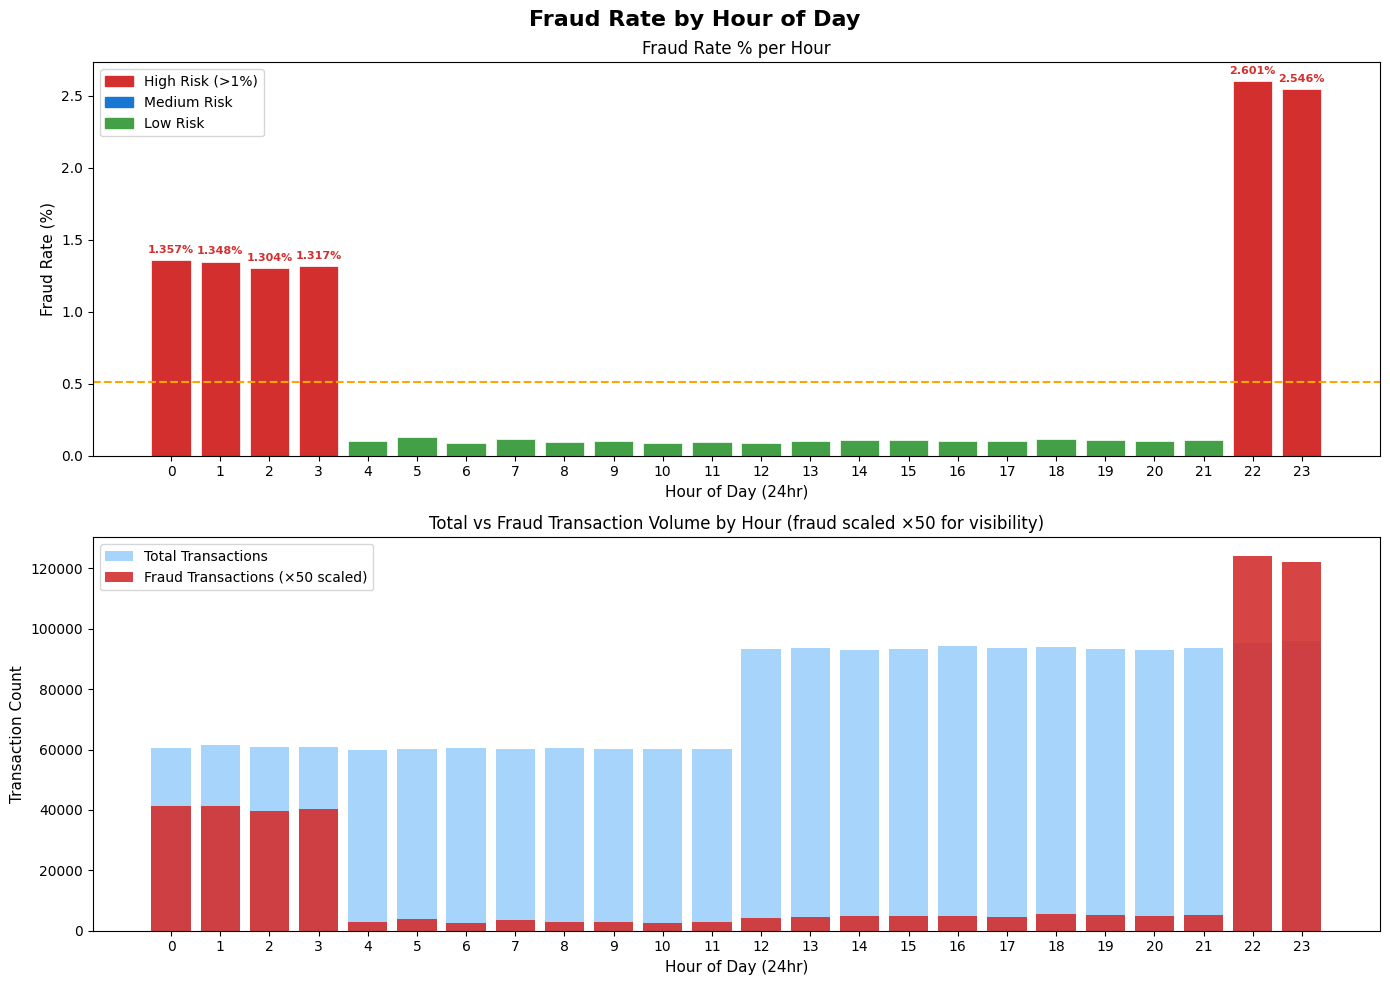

Chart saved to reports/


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Fraud Rate by Hour of Day', fontsize=16, fontweight='bold', y=0.98)

# --- Chart 1: Bar chart - fraud % by hour ---
colors = ['#d32f2f' if p > 1.0 else '#1976d2' if p > 0.15 else '#43a047' 
          for p in df['fraud_pct']]

axes[0].bar(df['hour_of_day'], df['fraud_pct'], color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Hour of Day (24hr)', fontsize=11)
axes[0].set_ylabel('Fraud Rate (%)', fontsize=11)
axes[0].set_title('Fraud Rate % per Hour', fontsize=12)
axes[0].set_xticks(range(0, 24))
axes[0].axhline(y=df['fraud_pct'].mean(), color='orange', linestyle='--', 
                linewidth=1.5, label=f"Avg: {df['fraud_pct'].mean():.3f}%")
axes[0].legend()

# Add value labels on high risk bars
for i, row in df.iterrows():
    if row['fraud_pct'] > 1.0:
        axes[0].text(row['hour_of_day'], row['fraud_pct'] + 0.05, 
                    f"{row['fraud_pct']}%", ha='center', fontsize=8, color='#d32f2f', fontweight='bold')

red_patch   = mpatches.Patch(color='#d32f2f', label='High Risk (>1%)')
blue_patch  = mpatches.Patch(color='#1976d2', label='Medium Risk')
green_patch = mpatches.Patch(color='#43a047', label='Low Risk')
axes[0].legend(handles=[red_patch, blue_patch, green_patch], loc='upper left')

# --- Chart 2: Total txns vs fraud txns overlay ---
x = df['hour_of_day']
axes[1].bar(x, df['total_txns'], color='#90caf9', label='Total Transactions', alpha=0.8)
axes[1].bar(x, df['fraud_txns'] * 50, color='#d32f2f', label='Fraud Transactions (×50 scaled)', alpha=0.9)
axes[1].set_xlabel('Hour of Day (24hr)', fontsize=11)
axes[1].set_ylabel('Transaction Count', fontsize=11)
axes[1].set_title('Total vs Fraud Transaction Volume by Hour (fraud scaled ×50 for visibility)', fontsize=12)
axes[1].set_xticks(range(0, 24))
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/02_fraud_rate_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/")

In [11]:
conn = sqlite3.connect("../data/credit_risk.db")

query = """
SELECT
    category,
    COUNT(*)                                         AS total_txns,
    SUM(is_fraud)                                    AS fraud_txns,
    ROUND(SUM(is_fraud) * 100.0 / COUNT(*), 3)      AS fraud_pct,
    ROUND(AVG(amt), 2)                               AS avg_amt,
    ROUND(SUM(CASE WHEN is_fraud=1 THEN amt ELSE 0 END), 2) AS total_fraud_amt
FROM transactions
GROUP BY category
ORDER BY fraud_pct DESC
"""

df_merchant = pd.read_sql_query(query, conn)
conn.close()

print(df_merchant.to_string(index=False))

      category  total_txns  fraud_txns  fraud_pct  avg_amt  total_fraud_amt
  shopping_net      139322        2219      1.593    86.94       2214847.64
      misc_net       90654        1182      1.304    80.18        944009.71
   grocery_pos      176191        2228      1.265   116.64        695664.62
  shopping_pos      166463        1056      0.634    78.91        928132.34
 gas_transport      188029         772      0.411    63.48          9442.53
      misc_pos      114229         322      0.282    62.68         68494.84
   grocery_net       64878         175      0.270    53.69          2108.21
        travel       57956         156      0.269   111.77          1399.47
 personal_care      130085         290      0.223    48.05          7571.96
 entertainment      134118         292      0.218    64.14        147399.96
     kids_pets      161727         304      0.188    57.53          5619.53
   food_dining      130729         205      0.157    50.99         24739.16
          ho

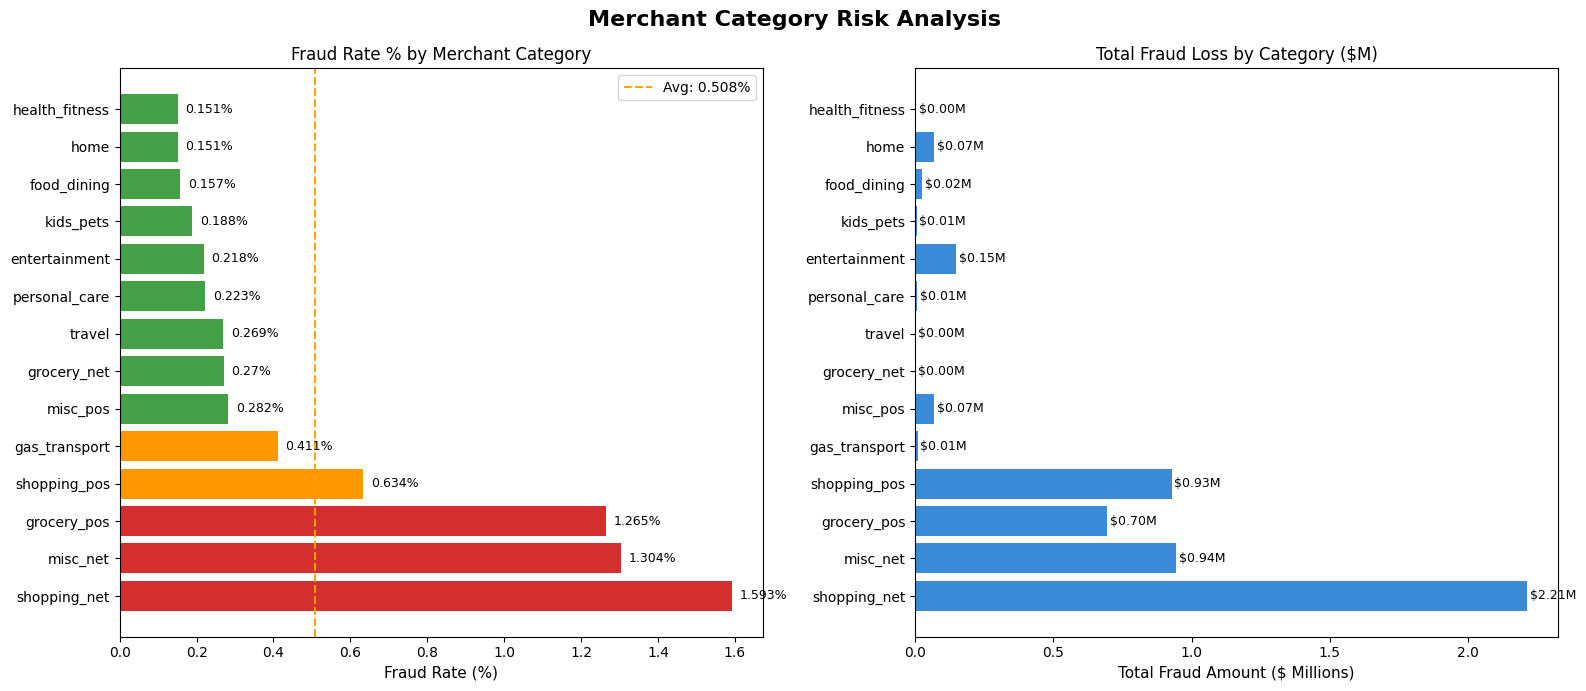

Chart saved!


In [12]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Merchant Category Risk Analysis', fontsize=16, fontweight='bold')

# --- Chart 1: Fraud % by category (horizontal bar) ---
colors = ['#d32f2f' if p > 1.0 else '#ff9800' if p > 0.4 else '#43a047' 
          for p in df_merchant['fraud_pct']]

axes[0].barh(df_merchant['category'], df_merchant['fraud_pct'], color=colors)
axes[0].set_xlabel('Fraud Rate (%)', fontsize=11)
axes[0].set_title('Fraud Rate % by Merchant Category', fontsize=12)
axes[0].axvline(x=df_merchant['fraud_pct'].mean(), color='orange', 
                linestyle='--', linewidth=1.5, label=f"Avg: {df_merchant['fraud_pct'].mean():.3f}%")
axes[0].legend()

# Add value labels
for i, (val, cat) in enumerate(zip(df_merchant['fraud_pct'], df_merchant['category'])):
    axes[0].text(val + 0.02, i, f"{val}%", va='center', fontsize=9)

# --- Chart 2: Total fraud amount by category ---
axes[1].barh(df_merchant['category'], 
             df_merchant['total_fraud_amt'] / 1e6, 
             color='#1976d2', alpha=0.85)
axes[1].set_xlabel('Total Fraud Amount ($ Millions)', fontsize=11)
axes[1].set_title('Total Fraud Loss by Category ($M)', fontsize=12)

for i, val in enumerate(df_merchant['total_fraud_amt'] / 1e6):
    axes[1].text(val + 0.01, i, f"${val:.2f}M", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/03_merchant_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [13]:
conn = sqlite3.connect("../data/credit_risk.db")

query = """
WITH ranked AS (
    SELECT
        cc_num,
        trans_date_trans_time,
        amt,
        is_fraud,
        unix_time,
        LAG(unix_time, 1) OVER (PARTITION BY cc_num ORDER BY unix_time) AS prev_1,
        LAG(unix_time, 2) OVER (PARTITION BY cc_num ORDER BY unix_time) AS prev_2,
        LAG(unix_time, 3) OVER (PARTITION BY cc_num ORDER BY unix_time) AS prev_3,
        LAG(unix_time, 4) OVER (PARTITION BY cc_num ORDER BY unix_time) AS prev_4
    FROM transactions
),
velocity AS (
    SELECT
        cc_num,
        trans_date_trans_time,
        amt,
        is_fraud,
        unix_time,
        CASE 
            WHEN (unix_time - prev_4) <= 3600 THEN 'HIGH VELOCITY'
            WHEN (unix_time - prev_2) <= 3600 THEN 'MEDIUM VELOCITY'
            ELSE 'NORMAL'
        END AS velocity_flag
    FROM ranked
    WHERE prev_4 IS NOT NULL
)
SELECT
    velocity_flag,
    COUNT(*)                                          AS total_txns,
    SUM(is_fraud)                                     AS fraud_txns,
    ROUND(SUM(is_fraud) * 100.0 / COUNT(*), 3)       AS fraud_pct,
    ROUND(AVG(amt), 2)                                AS avg_amt
FROM velocity
GROUP BY velocity_flag
ORDER BY fraud_pct DESC
"""

df_velocity = pd.read_sql_query(query, conn)
conn.close()

print(df_velocity.to_string(index=False))

  velocity_flag  total_txns  fraud_txns  fraud_pct  avg_amt
  HIGH VELOCITY         973         155     15.930   152.89
MEDIUM VELOCITY       43794        1422      3.247    83.79
         NORMAL     1803631        7703      0.427    69.60


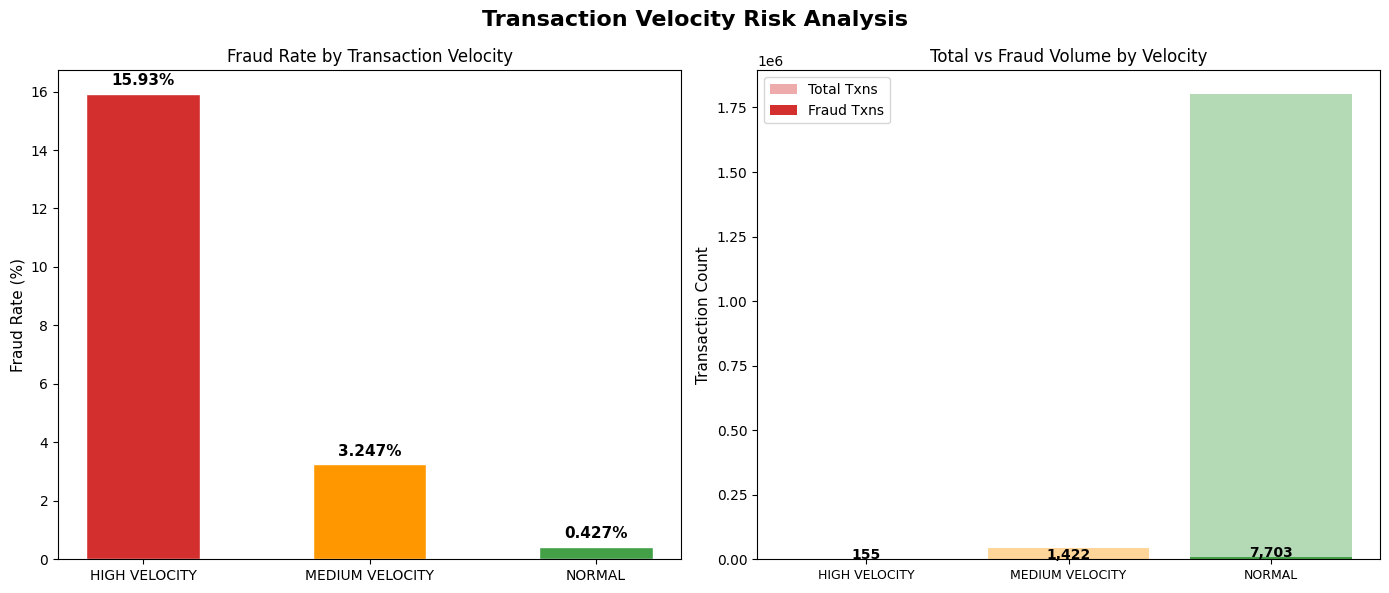

Saved!


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Transaction Velocity Risk Analysis', fontsize=16, fontweight='bold')

colors = {'HIGH VELOCITY': '#d32f2f', 'MEDIUM VELOCITY': '#ff9800', 'NORMAL': '#43a047'}
bar_colors = [colors[v] for v in df_velocity['velocity_flag']]

# --- Chart 1: Fraud % by velocity ---
bars = axes[0].bar(df_velocity['velocity_flag'], df_velocity['fraud_pct'], 
                   color=bar_colors, edgecolor='white', width=0.5)
axes[0].set_ylabel('Fraud Rate (%)', fontsize=11)
axes[0].set_title('Fraud Rate by Transaction Velocity', fontsize=12)

for bar, val in zip(bars, df_velocity['fraud_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{val}%", ha='center', fontsize=11, fontweight='bold')

# --- Chart 2: Volume breakdown ---
x = range(len(df_velocity))
axes[1].bar(x, df_velocity['total_txns'], color=bar_colors, alpha=0.4, label='Total Txns')
axes[1].bar(x, df_velocity['fraud_txns'], color=bar_colors, alpha=1.0, label='Fraud Txns')
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_velocity['velocity_flag'], fontsize=9)
axes[1].set_ylabel('Transaction Count', fontsize=11)
axes[1].set_title('Total vs Fraud Volume by Velocity', fontsize=12)
axes[1].legend()

for i, (total, fraud) in enumerate(zip(df_velocity['total_txns'], df_velocity['fraud_txns'])):
    axes[1].text(i, fraud + 200, f"{fraud:,}", ha='center', fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig('../reports/04_velocity_checks.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [15]:
conn = sqlite3.connect("../data/credit_risk.db")

query = """
WITH velocity_flags AS (
    SELECT
        cc_num,
        trans_date_trans_time,
        amt,
        is_fraud,
        category,
        unix_time,
        CAST(strftime('%H', trans_date_trans_time) AS INTEGER) AS hour_of_day,
        LAG(unix_time, 4) OVER (PARTITION BY cc_num ORDER BY unix_time) AS prev_4
    FROM transactions
),
scored AS (
    SELECT
        cc_num,
        trans_date_trans_time,
        amt,
        is_fraud,
        category,
        hour_of_day,

        -- Signal 1: High risk hour (0-3am, 10pm-11pm)
        CASE WHEN hour_of_day BETWEEN 0 AND 3 
             OR hour_of_day IN (22,23) THEN 1 ELSE 0 END AS night_flag,

        -- Signal 2: High risk merchant category
        CASE WHEN category IN ('shopping_net','misc_net','grocery_pos') 
             THEN 1 ELSE 0 END AS merchant_flag,

        -- Signal 3: Velocity — 5 txns in 60 min
        CASE WHEN prev_4 IS NOT NULL 
             AND (unix_time - prev_4) <= 3600 THEN 1 ELSE 0 END AS velocity_flag,

        -- Signal 4: High amount (above avg fraud amount $530)
        CASE WHEN amt > 500 THEN 1 ELSE 0 END AS amount_flag

    FROM velocity_flags
),
risk_tiered AS (
    SELECT *,
        (night_flag + merchant_flag + velocity_flag + amount_flag) AS risk_score,
        CASE
            WHEN (night_flag + merchant_flag + velocity_flag + amount_flag) >= 3 THEN 'CRITICAL'
            WHEN (night_flag + merchant_flag + velocity_flag + amount_flag) = 2 THEN 'HIGH'
            WHEN (night_flag + merchant_flag + velocity_flag + amount_flag) = 1 THEN 'MEDIUM'
            ELSE 'LOW'
        END AS risk_tier
    FROM scored
)
SELECT
    risk_tier,
    COUNT(*)                                        AS total_txns,
    SUM(is_fraud)                                   AS fraud_txns,
    ROUND(SUM(is_fraud) * 100.0 / COUNT(*), 3)     AS fraud_pct,
    ROUND(AVG(amt), 2)                              AS avg_amt
FROM risk_tiered
GROUP BY risk_tier
ORDER BY 
    CASE risk_tier 
        WHEN 'CRITICAL' THEN 1 
        WHEN 'HIGH' THEN 2 
        WHEN 'MEDIUM' THEN 3 
        ELSE 4 
    END
"""

df_risk = pd.read_sql_query(query, conn)
conn.close()
print(df_risk.to_string(index=False))

risk_tier  total_txns  fraud_txns  fraud_pct  avg_amt
 CRITICAL        4414        2936     66.516   907.61
     HIGH      126333        3473      2.749   142.32
   MEDIUM      597889        2811      0.470    79.13
      LOW     1123758         431      0.038    53.83


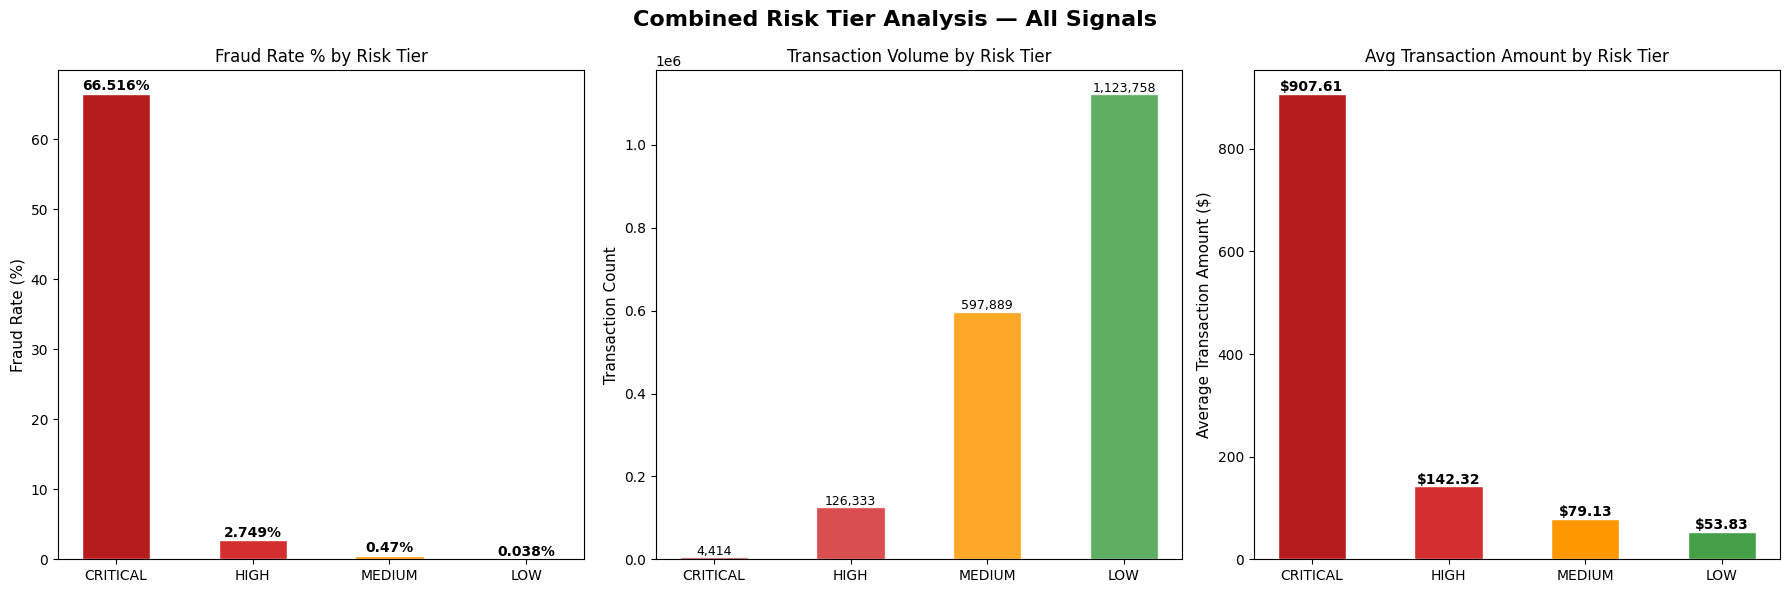

Saved!


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Combined Risk Tier Analysis — All Signals', fontsize=16, fontweight='bold')

colors = {'CRITICAL': '#b71c1c', 'HIGH': '#d32f2f', 'MEDIUM': '#ff9800', 'LOW': '#43a047'}
bar_colors = [colors[t] for t in df_risk['risk_tier']]

# --- Chart 1: Fraud % by tier ---
bars = axes[0].bar(df_risk['risk_tier'], df_risk['fraud_pct'], 
                   color=bar_colors, edgecolor='white', width=0.5)
axes[0].set_ylabel('Fraud Rate (%)', fontsize=11)
axes[0].set_title('Fraud Rate % by Risk Tier', fontsize=12)
for bar, val in zip(bars, df_risk['fraud_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val}%", ha='center', fontsize=10, fontweight='bold')

# --- Chart 2: Transaction volume ---
axes[1].bar(df_risk['risk_tier'], df_risk['total_txns'], 
            color=bar_colors, alpha=0.85, edgecolor='white', width=0.5)
axes[1].set_ylabel('Transaction Count', fontsize=11)
axes[1].set_title('Transaction Volume by Risk Tier', fontsize=12)
for i, (total, fraud) in enumerate(zip(df_risk['total_txns'], df_risk['fraud_txns'])):
    axes[1].text(i, total + 5000, f"{total:,}", ha='center', fontsize=9)

# --- Chart 3: Avg amount by tier ---
bars3 = axes[2].bar(df_risk['risk_tier'], df_risk['avg_amt'],
                    color=bar_colors, edgecolor='white', width=0.5)
axes[2].set_ylabel('Average Transaction Amount ($)', fontsize=11)
axes[2].set_title('Avg Transaction Amount by Risk Tier', fontsize=12)
for bar, val in zip(bars3, df_risk['avg_amt']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f"${val}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/05_high_risk_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")